# Entrenamiento Faster R-CNN

Primer intento :)

In [25]:
!pip install roboflow albumentations torchmetrics tqdm

## 1. Imports

In [26]:
import time
import json
import random
from pathlib import Path
from collections import defaultdict

import cv2
import torch
import numpy as np
import torchvision
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm import tqdm
from PIL import Image
from roboflow import Roboflow
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

## 2. Configuración

In [ ]:
CONFIG = {
    # Dataset Roboflow
    "roboflow_api_key": "API-KEY",
    "roboflow_workspace": "joses-workspace-nqi4z",
    "roboflow_project": "Carritos-Detector",
    "roboflow_version": 1,
    "dataset_dir": "./Carritos-Detector-1",

    # Split
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "test_ratio":  0.10,

    # Modelo
    "num_classes": 9 + 1,      # 9 clases + background
    "freeze_backbone": True,

    # Entrenamiento
    "epochs": 30,
    "batch_size": 2,
    "lr": 1e-3,
    "lr_step_size": 10,
    "lr_gamma": 0.1,
    "weight_decay": 5e-4,
    "num_workers": 2,
    "seed": 42,

    # Evaluación
    "iou_thresholds": [0.50, 0.75],
    "score_threshold": 0.5,

    # Checkpoints
    "checkpoint_dir": "./checkpoints",
    "save_every": 5,
}

In [28]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {DEVICE}")

[INFO] Usando dispositivo: cuda


In [29]:
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

## 3. Dataset
El dataset fue hecho manualmente desde Roboflow. El grupo estuvo clasificando todas las imagenes y asignando cada objeto una clase respectiva.

Para poder usarlo, usamos la vía de cargarla desde la nube que ofrece el mismo Roboflow.

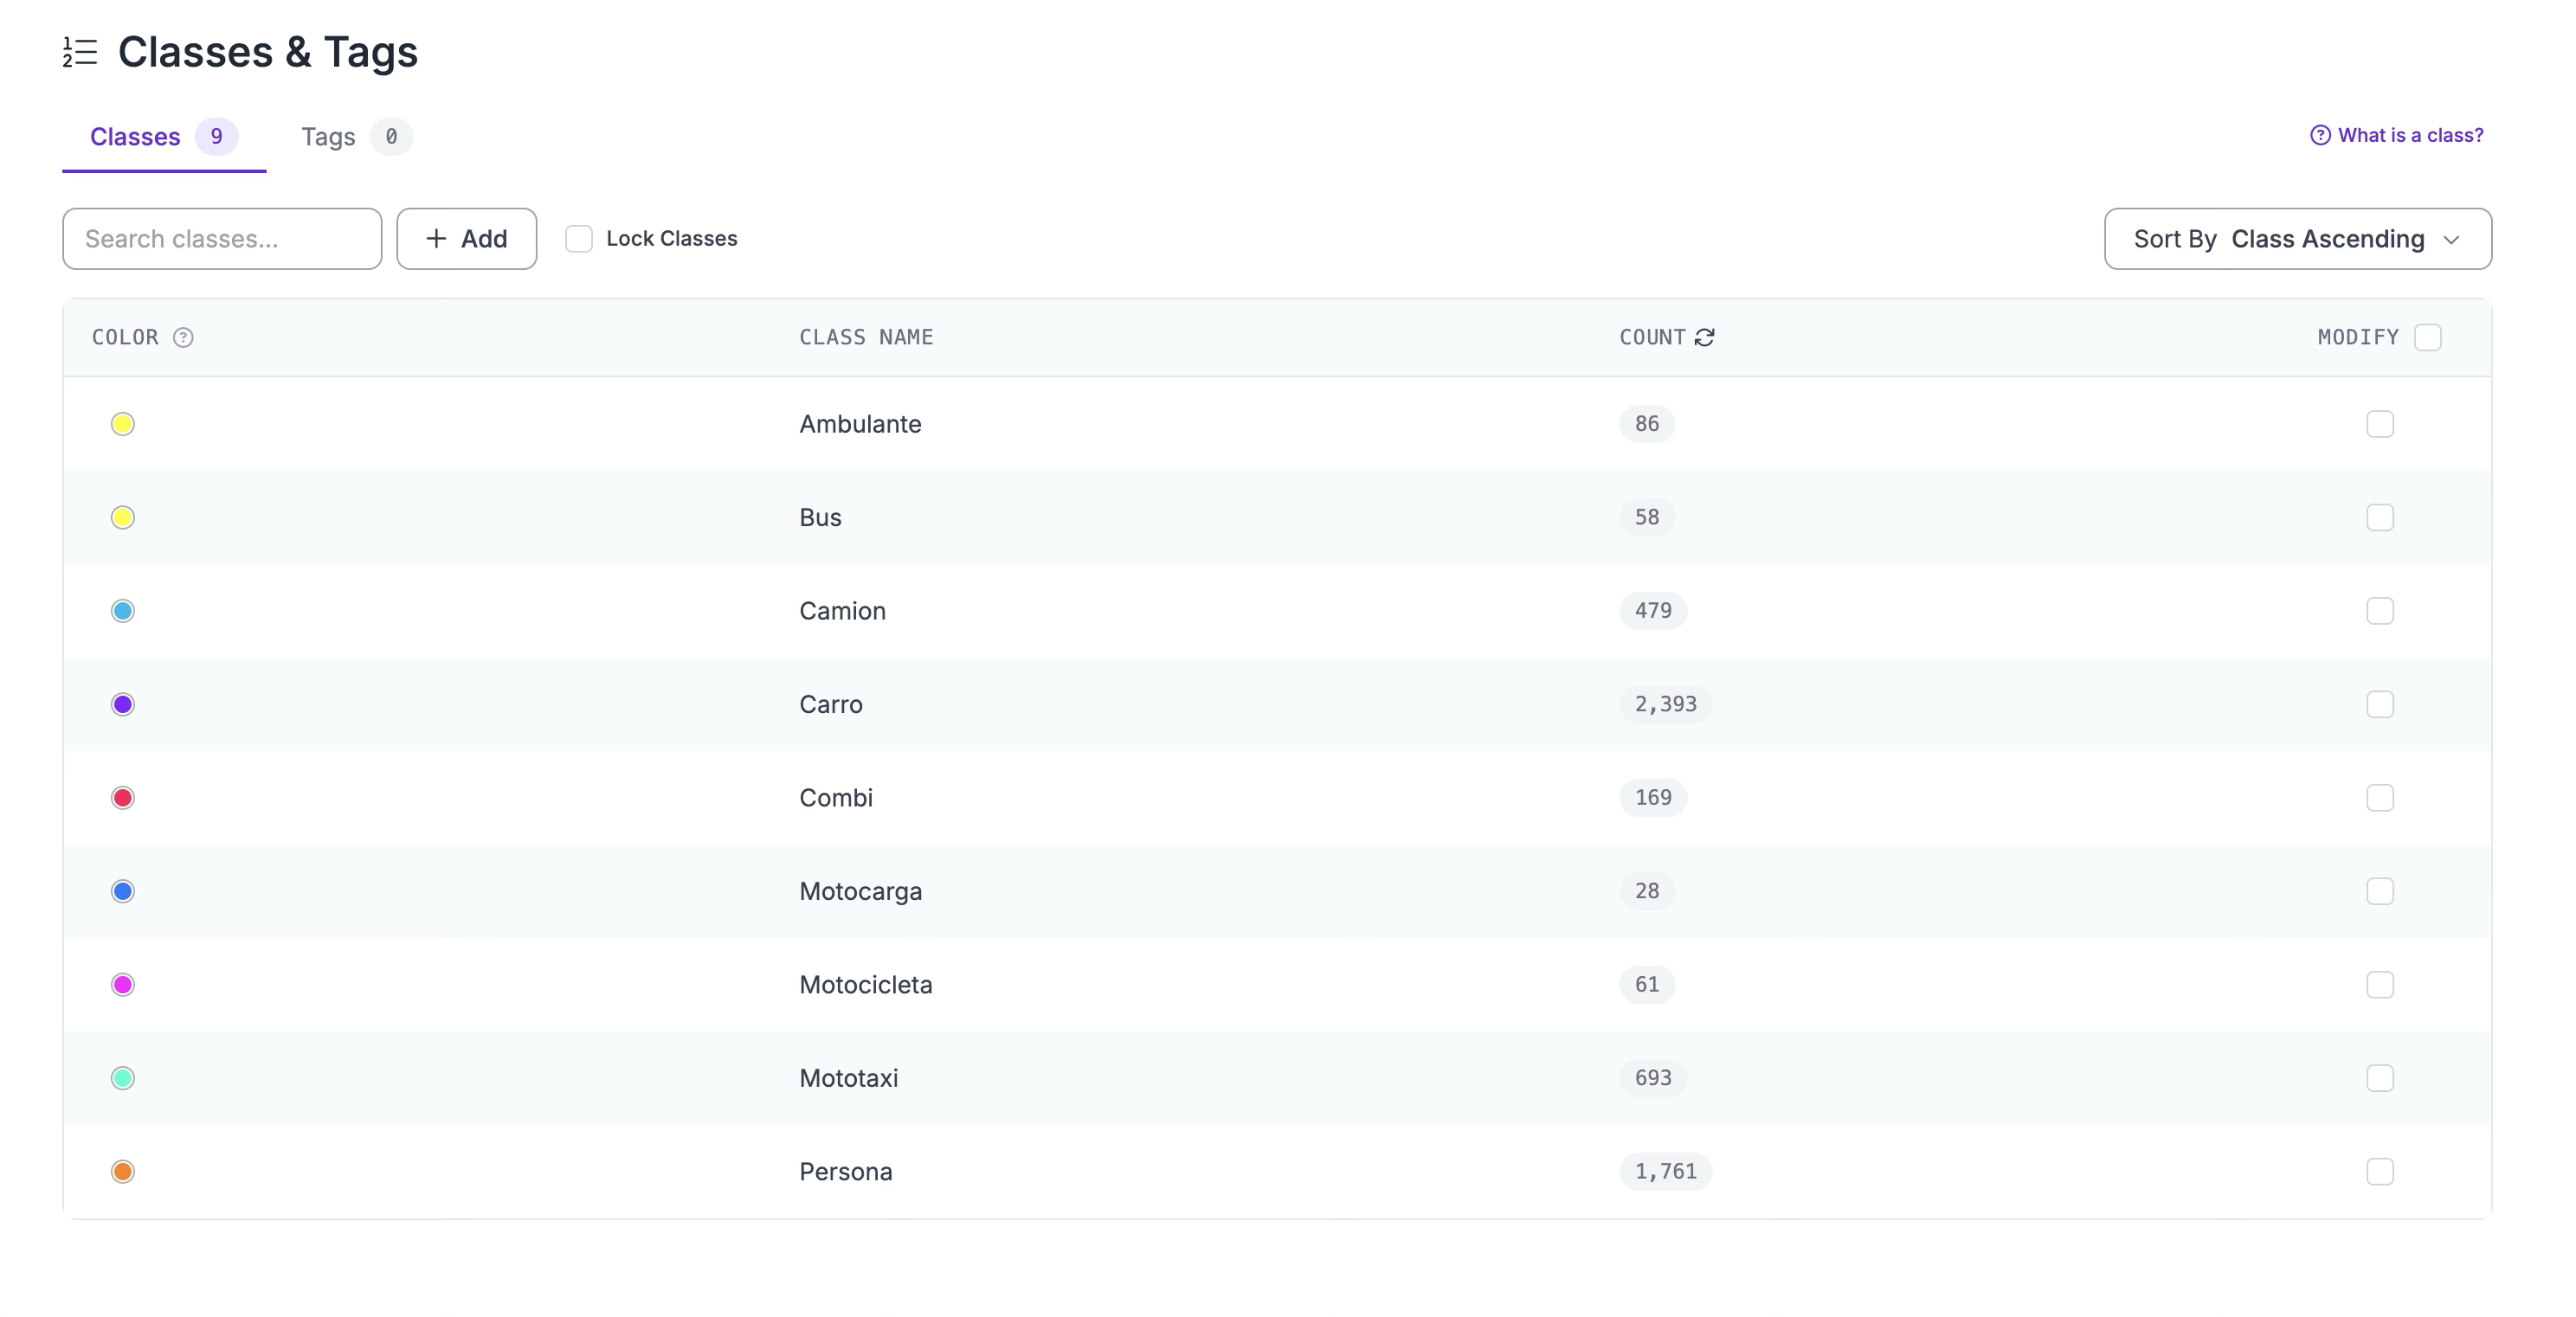

In [ ]:
dataset_dir = Path(CONFIG["dataset_dir"])
if dataset_dir.exists():
    print(f"[INFO] Dataset ya encontrado en: {dataset_dir}")
else:
    print("[INFO] Descargando dataset desde Roboflow...")
    rf = Roboflow(api_key=CONFIG["roboflow_api_key"])
    project = rf.workspace("joses-workspace-nqi4z").project("Carritos-Detector")
    dataset = project.version(1).download("coco")

[INFO] Dataset ya encontrado en: Carritos-Detector-1


## 4. Parseo de anotaciones COCO y splits

In [31]:
def load_coco_annotations(json_path: str):
    with open(json_path, "r") as f:
        coco = json.load(f)
    categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
    ann_by_image = defaultdict(list)
    for ann in coco["annotations"]:
        ann_by_image[ann["image_id"]].append(ann)
    images = [img for img in coco["images"] if ann_by_image[img["id"]]]
    return images, ann_by_image, categories

In [32]:
# Detectar splits de Roboflow (train/valid/test)
roboflow_splits = {
    "train": dataset_dir / "train",
    "val":   dataset_dir / "valid",
    "test":  dataset_dir / "test",
}
has_roboflow_splits = all(
    (p / "_annotations.coco.json").exists() for p in roboflow_splits.values()
)

if has_roboflow_splits:
    print("[INFO] Splits de Roboflow detectados (train/valid/test).")
    splits = {}
    categories = None
    for split_name, split_dir in roboflow_splits.items():
        images, ann_by_image, cats = load_coco_annotations(
            str(split_dir / "_annotations.coco.json")
        )
        splits[split_name] = {
            "images": images,
            "ann_by_image": ann_by_image,
            "img_dir": split_dir,
        }
        if categories is None:
            categories = cats
else:
    all_jsons = list(dataset_dir.rglob("_annotations.coco.json"))
    if not all_jsons:
        raise FileNotFoundError(f"No se encontró ningún _annotations.coco.json en {dataset_dir}")
    json_path = all_jsons[0]
    img_dir = json_path.parent
    print(f"[INFO] Split manual 80/10/10 desde: {json_path}")
    images, ann_by_image, categories = load_coco_annotations(str(json_path))
    random.shuffle(images)
    n = len(images)
    n_train = int(n * CONFIG["train_ratio"])
    n_val = int(n * CONFIG["val_ratio"])
    splits = {
        "train": {"images": images[:n_train], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "val":   {"images": images[n_train:n_train+n_val], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "test":  {"images": images[n_train+n_val:], "ann_by_image": ann_by_image, "img_dir": img_dir},
    }

print(f"[INFO] Clases: {categories}")
print(f"[INFO] Imágenes → train: {len(splits['train']['images'])} | "
      f"val: {len(splits['val']['images'])} | test: {len(splits['test']['images'])}")

[INFO] Splits de Roboflow detectados (train/valid/test).
[INFO] Clases: {0: 'Carritos-Detector', 1: 'Ambulante', 2: 'Bus', 3: 'Camion', 4: 'Carro', 5: 'Combi', 6: 'Motocarga', 7: 'Motocicleta', 8: 'Mototaxi', 9: 'Persona'}
[INFO] Imágenes → train: 807 | val: 101 | test: 101


## 5. Data Augmentation

In [33]:
def get_transforms(split: str):
    if split == "train":
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, p=0.5),
            A.RandomResizedCrop(size=(640, 640), scale=(0.7, 1.0), ratio=(0.75, 1.33), p=0.5),
            A.Resize(640, 640),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            A.RandomBrightnessContrast(p=0.4),
            A.CLAHE(p=0.2),
            A.CoarseDropout(num_holes_range=(3, 6), height_range=(20, 40), width_range=(20, 40), fill_value=0, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=100, min_visibility=0.3))
    else:
        return A.Compose([
            A.Resize(640, 640),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=1, min_visibility=0.1))

## 6. Dataset PyTorch y DataLoaders

In [34]:
class COCODetectionDataset(Dataset):
    def __init__(self, images, ann_by_image, img_dir, transforms=None):
        self.images = images
        self.ann_by_image = ann_by_image
        self.img_dir = Path(img_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image_id = img_info["id"]
        img_path = self.img_dir / img_info["file_name"]

        image = cv2.imread(str(img_path))
        if image is None:
            raise FileNotFoundError(f"No se pudo cargar: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        anns = self.ann_by_image[image_id]
        bboxes = [ann["bbox"] for ann in anns]
        category_ids = [ann["category_id"] for ann in anns]

        if self.transforms:
            augmented = self.transforms(image=image, bboxes=bboxes, category_ids=category_ids)
            image = augmented["image"]
            bboxes = augmented["bboxes"]
            category_ids = augmented["category_ids"]

        if len(bboxes) > 0:
            bboxes_np = np.array(bboxes, dtype=np.float32)
            boxes = np.stack([
                bboxes_np[:, 0], bboxes_np[:, 1],
                bboxes_np[:, 0] + bboxes_np[:, 2],
                bboxes_np[:, 1] + bboxes_np[:, 3],
            ], axis=1)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(category_ids, dtype=torch.int64)
            areas = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros(len(labels), dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([image_id]),
                  "area": areas, "iscrowd": iscrowd}

        if not self.transforms:
            image = torchvision.transforms.functional.to_tensor(Image.fromarray(image))

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [35]:
train_ds = COCODetectionDataset(
    images=splits["train"]["images"], ann_by_image=splits["train"]["ann_by_image"],
    img_dir=splits["train"]["img_dir"], transforms=get_transforms("train"),
)
val_ds = COCODetectionDataset(
    images=splits["val"]["images"], ann_by_image=splits["val"]["ann_by_image"],
    img_dir=splits["val"]["img_dir"], transforms=get_transforms("val"),
)
test_ds = COCODetectionDataset(
    images=splits["test"]["images"], ann_by_image=splits["test"]["ann_by_image"],
    img_dir=splits["test"]["img_dir"], transforms=get_transforms("test"),
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)

print(f"[INFO] Imágenes → train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

[INFO] Imágenes → train: 807 | val: 101 | test: 101


Argument(s) 'var_limit' are not valid for transform GaussNoise
Argument(s) 'height_range, width_range, fill_value' are not valid for transform CoarseDropout


## 7. Modelo: Faster R-CNN (ResNet-50-FPN)

In [36]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# Congelar backbone (ResNet-50)
for name, param in model.backbone.body.named_parameters():
    param.requires_grad = False
print("[INFO] Backbone (ResNet-50) congelado.")

# Reemplazar cabezal de predicción
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CONFIG["num_classes"])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"[INFO] Parámetros entrenables: {trainable:,} / {total:,}")

model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 168MB/s]  


[INFO] Backbone (ResNet-50) congelado.
[INFO] Parámetros entrenables: 17,885,249 / 41,340,161


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## 8. Optimizador, Scheduler y Checkpoints

In [37]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=CONFIG["lr"], momentum=0.9, weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=CONFIG["lr_step_size"], gamma=CONFIG["lr_gamma"])

ckpt_dir = Path(CONFIG["checkpoint_dir"])
ckpt_dir.mkdir(parents=True, exist_ok=True)

best_map50 = 0.0
history = []

## 9. Función de entrenamiento (una época)

In [38]:
def train_one_epoch(model, optimizer, loader, epoch):
    model.train()
    total_loss = 0.0
    loss_cls_sum = 0.0
    loss_box_sum = 0.0
    loss_obj_sum = 0.0
    loss_rpn_sum = 0.0

    pbar = tqdm(loader, desc=f"Época {epoch+1} [TRAIN]", leave=True)
    for images, targets in pbar:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        loss_cls_sum += loss_dict.get("loss_classifier", torch.tensor(0.)).item()
        loss_box_sum += loss_dict.get("loss_box_reg", torch.tensor(0.)).item()
        loss_obj_sum += loss_dict.get("loss_objectness", torch.tensor(0.)).item()
        loss_rpn_sum += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "cls": f"{loss_dict.get('loss_classifier', torch.tensor(0.)).item():.3f}",
            "box": f"{loss_dict.get('loss_box_reg', torch.tensor(0.)).item():.3f}",
        })

    n = len(loader)
    return {
        "loss_total": total_loss / n, "loss_cls": loss_cls_sum / n,
        "loss_box": loss_box_sum / n, "loss_obj": loss_obj_sum / n,
        "loss_rpn": loss_rpn_sum / n,
    }

## 10. Función de evaluación (mAP, F1)

In [39]:
def _box_iou_single(box_a, box_b):
    area_a = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])
    area_b = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])
    inter_x1 = torch.max(box_a[:, None, 0], box_b[None, :, 0])
    inter_y1 = torch.max(box_a[:, None, 1], box_b[None, :, 1])
    inter_x2 = torch.min(box_a[:, None, 2], box_b[None, :, 2])
    inter_y2 = torch.min(box_a[:, None, 3], box_b[None, :, 3])
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    union_area = area_a[:, None] + area_b[None, :] - inter_area
    return inter_area / union_area.clamp(min=1e-6)


In [40]:
def _accumulate_f1(pred_boxes, pred_labels, gt_boxes, gt_labels,
                   iou_threshold, tp, fp, fn, num_classes):
    gt_boxes = gt_boxes.cpu()
    gt_labels = gt_labels.cpu()
    pred_boxes = pred_boxes.cpu()
    gt_matched = torch.zeros(len(gt_labels), dtype=torch.bool)

    if len(pred_boxes) > 0 and len(gt_boxes) > 0:
        iou_matrix = _box_iou_single(pred_boxes, gt_boxes)
        for pred_idx in range(len(pred_boxes)):
            pred_cls = pred_labels[pred_idx].item()
            best_iou, best_gt = iou_matrix[pred_idx].max(dim=0)
            best_iou, best_gt = best_iou.item(), best_gt.item()
            if best_iou >= iou_threshold and not gt_matched[best_gt] and gt_labels[best_gt].item() == pred_cls:
                tp[pred_cls] += 1
                gt_matched[best_gt] = True
            else:
                fp[pred_cls] += 1
    else:
        for pred_cls in pred_labels.tolist():
            fp[pred_cls] += 1

    for gt_idx in range(len(gt_labels)):
        if not gt_matched[gt_idx]:
            fn[gt_labels[gt_idx].item()] += 1


In [42]:
def evaluate(model, loader, split_name, categories, score_threshold=0.5):
    model.eval()
    metric_map = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.50, 0.75], class_metrics=True)
    num_classes = CONFIG["num_classes"]
    tp, fp, fn = defaultdict(int), defaultdict(int), defaultdict(int)

    pbar = tqdm(loader, desc=f"Evaluando [{split_name.upper()}]", leave=True)
    with torch.no_grad():
        for images, targets in pbar:
            images = [img.to(DEVICE) for img in images]
            targets_cpu = targets
            outputs = model(images)

            preds_tm, target_tm = [], []
            for output, target in zip(outputs, targets_cpu):
                keep = output["scores"] >= score_threshold
                boxes = output["boxes"][keep].cpu()
                labels = output["labels"][keep].cpu()
                scores = output["scores"][keep].cpu()
                preds_tm.append({"boxes": boxes, "labels": labels, "scores": scores})
                target_tm.append({"boxes": target["boxes"].cpu(), "labels": target["labels"].cpu()})
                _accumulate_f1(boxes, labels, target["boxes"], target["labels"],
                               iou_threshold=0.5, tp=tp, fp=fp, fn=fn, num_classes=num_classes)
            metric_map.update(preds_tm, target_tm)

    map_result = metric_map.compute()
    map50 = map_result["map_50"].item()
    map75 = map_result["map_75"].item()
    map_all = map_result["map"].item()

    f1_per_class, precision_per_class, recall_per_class = {}, {}, {}
    for c in range(1, num_classes):
        p = tp[c] / (tp[c] + fp[c] + 1e-9)
        r = tp[c] / (tp[c] + fn[c] + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)
        class_name = categories.get(c, f"class_{c}")
        f1_per_class[class_name] = round(f1, 4)
        precision_per_class[class_name] = round(p, 4)
        recall_per_class[class_name] = round(r, 4)

    macro_f1 = np.mean(list(f1_per_class.values()))

    sep = "───────────────────────────────────────────────────────"
    print(f"\n{sep}")
    print(f"  [{split_name.upper()}] Métricas de Evaluación")
    print(f"{sep}")
    print(f"  mAP@50      : {map50:.4f}")
    print(f"  mAP@75      : {map75:.4f}")
    print(f"  mAP@50:95   : {map_all:.4f}")
    print(f"  F1 macro    : {macro_f1:.4f}")
    print(f"\n  F1 por clase:")
    for cls_name, f1 in f1_per_class.items():
        prec = precision_per_class[cls_name]
        rec = recall_per_class[cls_name]
        print(f"    {cls_name:20s}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")
    print(f"{sep}\n")

    return {"map50": map50, "map75": map75, "map_all": map_all,
            "macro_f1": macro_f1, "f1_per_class": f1_per_class}


## 11. Loop de entrenamiento

In [43]:
for epoch in range(CONFIG["epochs"]):
    t0 = time.time()

    # Entrenar una época
    train_metrics = train_one_epoch(model, optimizer, train_loader, epoch)
    scheduler.step()

    # Validación cada 2 épocas
    if (epoch + 1) % 2 == 0 or epoch == CONFIG["epochs"] - 1:
        val_metrics = evaluate(model, val_loader, "val", categories, score_threshold=CONFIG["score_threshold"])
    else:
        val_metrics = {"map50": 0.0, "map75": 0.0, "map_all": 0.0, "macro_f1": 0.0}

    elapsed = time.time() - t0
    lr_now = scheduler.get_last_lr()[0]

    print(f"[Época {epoch+1:03d}/{CONFIG['epochs']}] "
          f"Loss={train_metrics['loss_total']:.4f} | "
          f"mAP@50={val_metrics['map50']:.4f} | "
          f"F1={val_metrics['macro_f1']:.4f} | "
          f"LR={lr_now:.6f} | {elapsed:.1f}s")

    history.append({
        "epoch": epoch + 1, "lr": lr_now,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    # Guardar mejor modelo
    if val_metrics["map50"] > best_map50:
        best_map50 = val_metrics["map50"]
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_map50": best_map50,
            "categories": categories,
            "config": CONFIG,
        }, ckpt_dir / "best_model.pth")
        print(f"  ✓ Mejor modelo guardado (mAP@50={best_map50:.4f})")

    # Checkpoint periódico
    if (epoch + 1) % CONFIG["save_every"] == 0:
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history, "categories": categories, "config": CONFIG,
        }, ckpt_dir / f"checkpoint_epoch{epoch+1:03d}.pth")

Época 1 [TRAIN]: 100%|██████████| 404/404 [01:58<00:00,  3.40it/s, loss=0.4161, cls=0.186, box=0.129]


[Época 001/30] Loss=0.8596 | mAP@50=0.0000 | F1=0.0000 | LR=0.001000 | 118.7s


Evaluando [VAL]: 100%|██████████| 51/51 [00:09<00:00,  5.51it/s]



───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.0562
  mAP@75      : 0.0288
  mAP@50:95   : 0.0425
  F1 macro    : 0.0696

  F1 por clase:
    Ambulante             P=0.000  R=0.000  F1=0.000
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=0.000  R=0.000  F1=0.000
    Carro                 P=0.679  R=0.545  F1=0.604
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.000  R=0.000  F1=0.000
    Mototaxi              P=1.000  R=0.011  F1=0.022
    Persona               P=0.000  R=0.000  F1=0.000
───────────────────────────────────────────────────────

[Época 002/30] Loss=0.7750 | mAP@50=0.0562 | F1=0.0696 | LR=0.001000 | 128.1s
  ✓ Mejor modelo guardado (mAP@50=0.0562)


Época 3 [TRAIN]: 100%|██████████| 404/404 [01:58<00:00,  3.40it/s, loss=1.2899, cls=0.596, box=0.527]


...


───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.1921
  mAP@75      : 0.0837
  mAP@50:95   : 0.1379
  F1 macro    : 0.2200

  F1 por clase:
    Ambulante             P=0.000  R=0.000  F1=0.000
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=0.444  R=0.098  F1=0.160
    Carro                 P=0.547  R=0.807  F1=0.652
    Combi                 P=1.000  R=0.071  F1=0.133
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.000  R=0.000  F1=0.000
    Mototaxi              P=0.556  R=0.659  F1=0.603
    Persona               P=0.378  R=0.503  F1=0.432
───────────────────────────────────────────────────────

[Época 028/30] Loss=0.6792 | mAP@50=0.1921 | F1=0.2200 | LR=0.000010 | 128.3s


Época 29 [TRAIN]: 100%|██████████| 404/404 [01:58<00:00,  3.41it/s, loss=0.4300, cls=0.208, box=0.126]


[Época 029/30] Loss=0.6747 | mAP@50=0.0000 | F1=0.0000 | LR=0.000010 | 118.6s


Evaluando [VAL]: 100%|██████████| 51/51 [00:09<00:00,  5.51it/s]



───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.1901
  mAP@75      : 0.0845
  mAP@50:95   : 0.1373
  F1 macro    : 0.2196

  F1 por clase:
    Ambulante             P=0.000  R=0.000  F1=0.000
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=0.444  R=0.098  F1=0.160
    Carro                 P=0.556  R=0.812  F1=0.660
    Combi                 P=1.000  R=0.071  F1=0.133
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.000  R=0.000  F1=0.000
    Mototaxi              P=0.541  R=0.648  F1=0.590
    Persona               P=0.384  R=0.497  F1=0.433
───────────────────────────────────────────────────────

[Época 030/30] Loss=0.6861 | mAP@50=0.1901 | F1=0.2196 | LR=0.000001 | 128.1s


## 12. Visualización del historial de entrenamiento

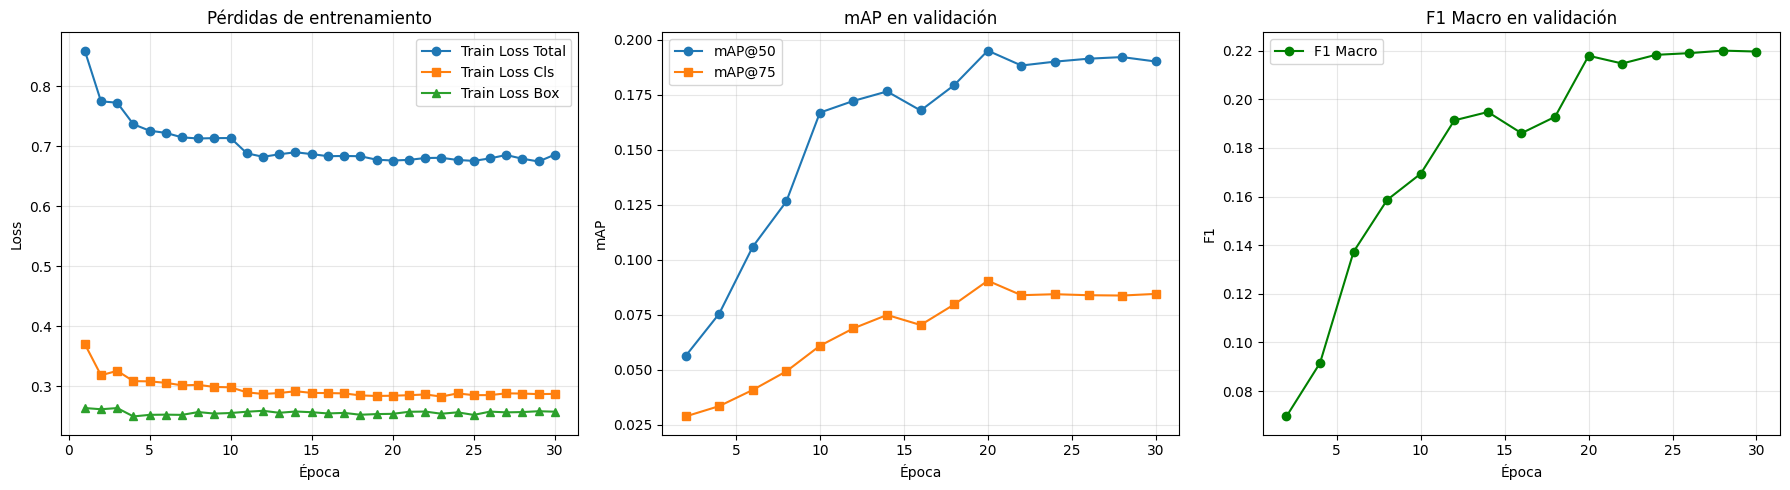

In [44]:
import pandas as pd

df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(df["epoch"], df["train_loss_total"], label="Train Loss Total", marker="o")
axes[0].plot(df["epoch"], df["train_loss_cls"], label="Train Loss Cls", marker="s")
axes[0].plot(df["epoch"], df["train_loss_box"], label="Train Loss Box", marker="^")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdidas de entrenamiento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP
val_epochs = df[df["val_map50"] > 0]["epoch"]
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map50"], label="mAP@50", marker="o")
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map75"], label="mAP@75", marker="s")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("mAP")
axes[1].set_title("mAP en validación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(val_epochs, df[df["val_map50"] > 0]["val_macro_f1"], label="F1 Macro", marker="o", color="green")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("F1")
axes[2].set_title("F1 Macro en validación")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Evaluación final en Test

In [45]:
# Cargar mejor modelo
best_ckpt = torch.load(ckpt_dir / "best_model.pth", map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"[INFO] Modelo de época {best_ckpt['epoch']} cargado (mAP@50 val: {best_ckpt['best_map50']:.4f})")

[INFO] Modelo de época 20 cargado (mAP@50 val: 0.1950)


In [46]:
test_metrics = evaluate(model, test_loader, "test", categories, score_threshold=CONFIG["score_threshold"])
print(f"\n[INFO] Mejor mAP@50 (val): {best_map50:.4f}")
print(f"[INFO] mAP@50 (test):      {test_metrics['map50']:.4f}")
print(f"[INFO] F1 macro (test):    {test_metrics['macro_f1']:.4f}")

Evaluando [TEST]: 100%|██████████| 51/51 [00:09<00:00,  5.54it/s]



───────────────────────────────────────────────────────
  [TEST] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.1769
  mAP@75      : 0.0721
  mAP@50:95   : 0.1245
  F1 macro    : 0.2029

  F1 por clase:
    Ambulante             P=0.000  R=0.000  F1=0.000
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=0.500  R=0.200  F1=0.286
    Carro                 P=0.548  R=0.698  F1=0.614
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.000  R=0.000  F1=0.000
    Mototaxi              P=0.465  R=0.702  F1=0.559
    Persona               P=0.362  R=0.372  F1=0.367
───────────────────────────────────────────────────────


[INFO] Mejor mAP@50 (val): 0.1950
[INFO] mAP@50 (test):      0.1769
[INFO] F1 macro (test):    0.2029


In [47]:
results = {
    "config": CONFIG, "categories": categories,
    "best_epoch": best_ckpt["epoch"], "best_map50": best_map50,
    "test_metrics": test_metrics, "history": history,
}
with open(ckpt_dir / "training_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"[INFO] Resultados guardados en: {ckpt_dir / 'training_results.json'}")

[INFO] Resultados guardados en: checkpoints/training_results.json


## 14. Visualización de predicciones en test

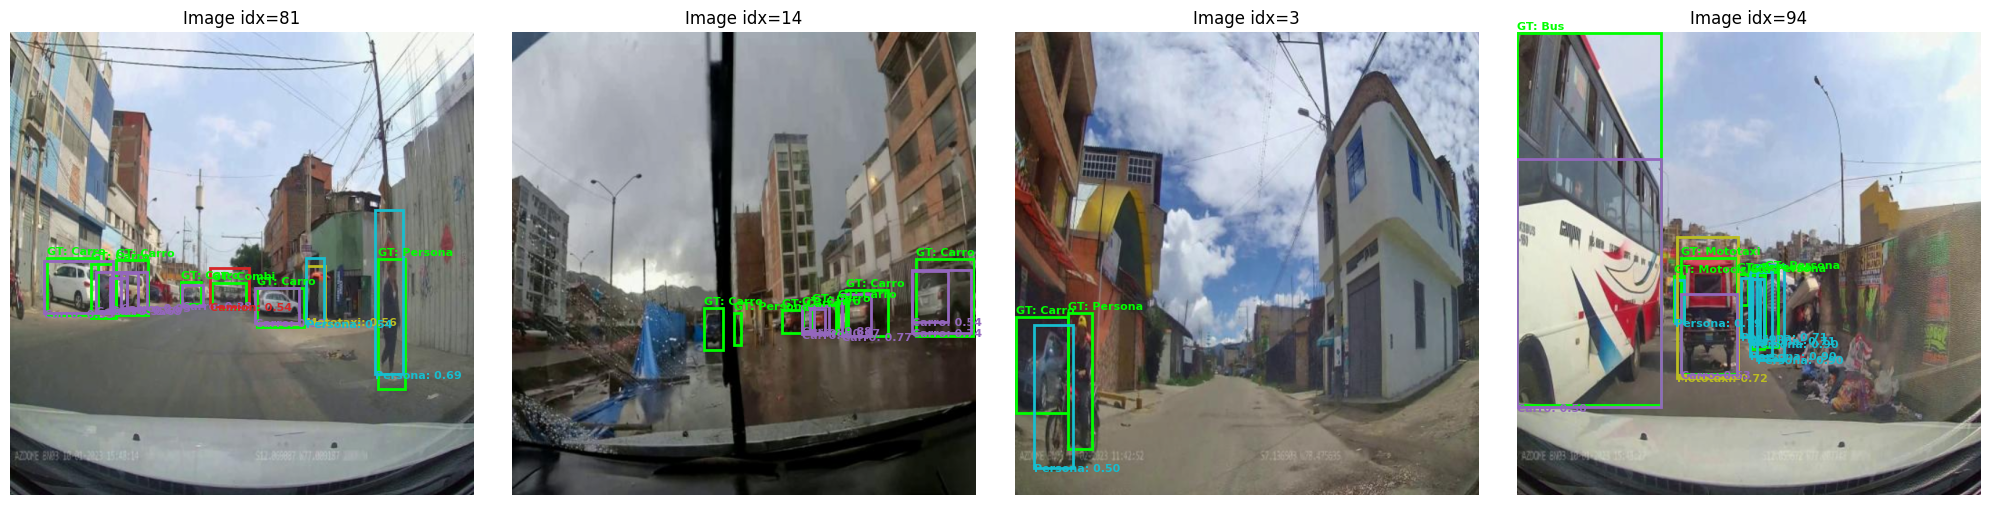

In [48]:
def visualize_predictions(model, dataset, categories, num_samples=4, score_threshold=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]

    class_colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        with torch.no_grad():
            pred = model([image.to(DEVICE)])[0]

        # Desnormalizar imagen para visualización
        img_np = image.cpu().numpy().transpose(1, 2, 0)
        img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.set_title(f"Image idx={idx}")
        ax.axis("off")

        # GT boxes (verde)
        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()
        for box, label in zip(gt_boxes, gt_labels):
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[1] - 5, f"GT: {categories.get(label, label)}",
                    color="lime", fontsize=8, fontweight="bold")

        # Pred boxes (rojo)
        keep = pred["scores"] >= score_threshold
        pred_boxes = pred["boxes"][keep].cpu().numpy()
        pred_labels = pred["labels"][keep].cpu().numpy()
        pred_scores = pred["scores"][keep].cpu().numpy()
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            color = class_colors[label % len(class_colors)]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[3] + 5, f"{categories.get(label, label)}: {score:.2f}",
                    color=color, fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, categories, num_samples=4)
